# Chapter 13: Neural Networks

**MATH 4230 Capstone Project  |  Christian Rodriguez  |  Spring 2026**

**Dataset:** Student Lifestyle, Mental Health and Burnout Insight

---

<div style="font-style: italic; color: #2E75B6;">
Adding depth through hidden layers narrows the burnout prediction error beyond the best linear model, but the improvement over the best ensemble method is small enough that the neural network's inability to explain individual predictions is difficult to justify for a student wellbeing advising system.
</div>

---

In [11]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import time
import warnings

# ── Third-party: standard data science stack ──────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
RANDOM_STATE = 230
np.random.seed(RANDOM_STATE)

plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

# ── Output directories ────────────────────────────────────────────────────────
FIGURES_DIR = '../figures/ch13/'
RESULTS_DIR = '../results/ch13/'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Setup complete.')
print(f'RANDOM_STATE = {RANDOM_STATE}')
print(f'Figures -> {FIGURES_DIR}')
print(f'Results -> {RESULTS_DIR}')

Setup complete.
RANDOM_STATE = 230
Figures -> ../figures/ch13/
Results -> ../results/ch13/


---
> **Important: Chapter 13 is the only chapter in this report that uses all three data splits.**
>
> Every chapter from 3 through 12 used only the training set for model fitting and the test set for final evaluation.
> This chapter adds a third active role for the validation set: monitoring generalization during training so that
> learning can stop before the model memorizes the training data. The validation set has been held entirely unused
> since Chapter 2 for this exact purpose. Using it here, and only here, keeps every earlier test set evaluation
> free of contamination from validation-driven decisions.
---

In [12]:
# ── Load all three splits from Chapter 2 ─────────────────────────────────────
X_train = np.load('../results/X_train.npy')
X_val   = np.load('../results/X_val.npy')
X_test  = np.load('../results/X_test.npy')

y_train_reg = np.load('../results/y_train_reg.npy')
y_val_reg   = np.load('../results/y_val_reg.npy')
y_test_reg  = np.load('../results/y_test_reg.npy')

feature_names = joblib.load('../results/feature_names.pkl')

print('All three splits loaded successfully.')
print()
print(f'X_train shape : {X_train.shape}    ->  weight updates during backpropagation')
print(f'X_val   shape : {X_val.shape}    ->  independent validation check')
print(f'X_test  shape : {X_test.shape}   ->  final evaluation only (used once at the end)')
print()
print(f'y_train_reg : {y_train_reg.shape}   range [{y_train_reg.min():.2f}, {y_train_reg.max():.2f}]')
print(f'y_val_reg   : {y_val_reg.shape}    range [{y_val_reg.min():.2f}, {y_val_reg.max():.2f}]')
print(f'y_test_reg  : {y_test_reg.shape}   range [{y_test_reg.min():.2f}, {y_test_reg.max():.2f}]')
print()
print(f'Feature count : {len(feature_names)}')
print(f'Features      : {feature_names}')

All three splits loaded successfully.

X_train shape : (140000, 19)    ->  weight updates during backpropagation
X_val   shape : (20000, 19)    ->  independent validation check
X_test  shape : (40000, 19)   ->  final evaluation only (used once at the end)

y_train_reg : (140000,)   range [0.00, 10.00]
y_val_reg   : (20000,)    range [0.00, 10.00]
y_test_reg  : (40000,)   range [0.00, 9.65]

Feature count : 19
Features      : ['age', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'gender_Male', 'gender_Other', 'academic_year_2', 'academic_year_3', 'academic_year_4']


## §1. The Question

Do nonlinear interactions among screen time, social support, physical activity, and family expectation
improve burnout prediction beyond what the best ensemble method in Chapter 9 achieves, and is the accuracy
gain large enough to justify a model that cannot explain its predictions?

## §2. Method in Brief

A neural network organizes neurons into one or more hidden layers that sit between the input features and the
output prediction. Each neuron computes a weighted sum of its inputs and then passes the result through an
activation function called ReLU (short for rectified linear unit), which replaces any negative output with
zero and passes positive values unchanged. This nonlinearity is what allows stacked layers to represent
relationships that a plain weighted sum cannot capture.

The network learns by running forward through the layers to produce a prediction, computing the error against
the actual burnout score, and then running backpropagation backward through the layers to measure how much
each weight contributed to the error. Gradient descent then nudges every weight slightly in the direction
that reduces the loss, and this process repeats across many passes through the training data. Early stopping
monitors performance on a held-aside portion of the data after each pass and halts training once performance
stops improving for a set number of consecutive iterations, preventing the model from overfitting to patterns
that only exist in the training rows.

## §3. Why This Method?

All of the regression and ensemble methods tested in earlier chapters predict burnout as a direct function
of each feature's contribution: a coefficient, a node-split threshold, or a weighted vote across trees.
A neural network can discover interactions between features automatically through its hidden layers without
the analyst specifying those interactions in advance. The relationship between exam pressure and burnout
might be fundamentally different for students who also report low sleep hours than for those who sleep
adequately, and no earlier method in this report can capture that conditional dependency without
pre-specifying the interaction term. This chapter tests whether that representational capacity translates
into meaningful predictive improvement on the same data and the same held-out test set used throughout.

This chapter also serves as the report's methodological bookend: by comparing all three neural network
architectures directly against every earlier chapter result in Figure 13.2, we get a direct answer to
whether added architectural complexity earns its cost. The trade-off is real. Every earlier method in
this report produces something interpretable: a coefficient table, a feature importance ranking, a
decision tree path, or a support vector boundary. A neural network with hundreds or thousands of weights
distributes its prediction across parameters that have no intuitive meaning. In a student wellbeing
context where a counselor may need to explain to a student why they were flagged for intervention, or
where an administrator may challenge a model recommendation, the inability to point to specific features
and say "this is why" is a genuine constraint that accuracy numbers alone cannot resolve.

## §4. Data Setup

This chapter uses the same 19 standardized features prepared in Chapter 2 and carried forward throughout
the report, with burnout score as the continuous regression target.

**This is the only chapter in the report that uses all three data splits.** The 140,000-row training set
is used for weight updates during backpropagation. The model also internally holds back 10 percent of
those training rows as its own stopping criterion, so the actual weight-update portion is approximately
126,000 rows. The 20,000-row validation set is loaded here and evaluated independently after each model
finishes training, providing an uncontaminated out-of-sample check on data the model never touched during
learning. The 40,000-row test set is evaluated only once, after all architectural choices have been made
based on validation performance.

One clarification on the early stopping mechanism: the model's internal stopping criterion uses a random
10 percent slice of X_train, not X_val. The X_val set loaded here is kept separate and serves as an
independent generalization check that neither the training loop nor the stopping criterion ever sees.
Using the test set for any intermediate architectural decision would constitute data leakage and inflate
the reported results.

## §5. Analysis

Three fully connected neural network architectures are compared to find the right balance between model capacity and generalization. All three use the ReLU activation function and the Adam optimization algorithm for gradient descent. Early stopping halts training when the internal validation loss has not improved for 10 consecutive iterations, with a ceiling of 500 iterations. The only difference between the architectures is the depth and width of the hidden layers.

The architecture comparison is reported in two ways. Table 13.1 lists the architecture definitions and parameter counts. Figure 13.1 shows the training loss curves, while Figure 13.2 compares training, validation, and test RMSE across the three architectures. The validation RMSE is the selection metric because it uses data that was not used for weight updates.

In [13]:
# ── Utility: count trainable parameters ──────────────────────────────────────

def estimate_params(hidden_layers, n_features, n_outputs=1):
    # For each consecutive pair of layers: (in * out) weights + out biases
    layer_sizes = [n_features] + list(hidden_layers) + [n_outputs]
    total = 0

    for i in range(len(layer_sizes) - 1):
        total += layer_sizes[i] * layer_sizes[i + 1]   # weights
        total += layer_sizes[i + 1]                    # biases

    return total


# ── Utility: load test RMSE from prior chapter result files ──────────────────

def load_chapter_rmse(csv_paths, fallback=None, model_contains=None):
    """Load a Test RMSE value from one or more possible CSV paths.

    Parameters
    ----------
    csv_paths : str or list[str]
        One path or several possible paths to check.
    fallback : float or None
        Value used if no file is found.
    model_contains : str or list[str] or None
        Optional keyword filter for a Model column.
    """
    if isinstance(csv_paths, str):
        csv_paths = [csv_paths]

    if isinstance(model_contains, str):
        model_contains = [model_contains]

    for csv_path in csv_paths:
        try:
            if not os.path.exists(csv_path):
                continue

            df = pd.read_csv(csv_path)

            # Optional row filter for files that contain multiple models
            if model_contains is not None and "Model" in df.columns:
                mask = pd.Series(False, index=df.index)
                for keyword in model_contains:
                    mask = mask | df["Model"].astype(str).str.contains(keyword, case=False, na=False)
                df = df.loc[mask].copy()

            if len(df) == 0:
                continue

            # Priority 1: exact column name match
            for col_name in ["Test RMSE", "test_rmse", "test RMSE", "TestRMSE"]:
                if col_name in df.columns:
                    val = pd.to_numeric(df[col_name], errors="coerce").dropna()
                    if len(val) > 0:
                        return float(val.min()), csv_path

            # Priority 2: Metric / Value table format
            if "Metric" in df.columns and "Value" in df.columns:
                mask = df["Metric"].astype(str).str.contains("Test RMSE", case=False, na=False)
                if mask.any():
                    val = pd.to_numeric(df.loc[mask, "Value"], errors="coerce").dropna()
                    if len(val) > 0:
                        return float(val.iloc[0]), csv_path

            # Priority 3: any column whose name contains rmse
            rmse_cols = [c for c in df.columns if "rmse" in c.lower()]
            if rmse_cols:
                test_cols = [c for c in rmse_cols if "test" in c.lower()]
                target = test_cols[0] if test_cols else rmse_cols[0]
                val = pd.to_numeric(df[target], errors="coerce").dropna()
                if len(val) > 0:
                    return float(val.min()), csv_path

        except Exception:
            pass

    return fallback, "fallback" if fallback is not None else "not found"


# ── Architecture definitions and Table 13.1 ─────────────────────────────────

n_features = X_train.shape[1]

ARCHITECTURES = {
    "A": (64,),
    "B": (128, 64),
    "C": (256, 128, 64),
}

architecture_table = pd.DataFrame([
    {
        "Architecture": "A",
        "Hidden Layers": "(64,)",
        "Description": "One hidden layer with 64 neurons",
        "Trainable Parameters": estimate_params((64,), n_features)
    },
    {
        "Architecture": "B",
        "Hidden Layers": "(128, 64)",
        "Description": "Two hidden layers with 128 then 64 neurons",
        "Trainable Parameters": estimate_params((128, 64), n_features)
    },
    {
        "Architecture": "C",
        "Hidden Layers": "(256, 128, 64)",
        "Description": "Three hidden layers with 256, 128, then 64 neurons",
        "Trainable Parameters": estimate_params((256, 128, 64), n_features)
    },
])

architecture_table_path = os.path.join(RESULTS_DIR, "nn_architecture_table.csv")
architecture_table.to_csv(architecture_table_path, index=False)

print("Table 13.1: Neural network architecture definitions and parameter counts.")
display(architecture_table)
print(f"Saved: {architecture_table_path}")

Table 13.1: Neural network architecture definitions and parameter counts.


,Architecture,Hidden Layers,Description,Trainable Parameters
0,A,"(64,)",One hidden layer with 64 neurons,1345
1,B,"(128, 64)",Two hidden layers with 128 then 64 neurons,10881
2,C,"(256, 128, 64)","Three hidden layers with 256, 128, then 64 neu...",46337


Saved: ../results/ch13/nn_architecture_table.csv


In [14]:
# ── Train each architecture ───────────────────────────────────────────────────
#
# early_stopping=True: the model internally splits off 10% of X_train to use
# as its stopping criterion. X_val is NOT passed here. After training ends,
# we evaluate on X_val separately as a clean out-of-sample check.

results = {}

print(f"Training on {X_train.shape[0]:,} rows x {X_train.shape[1]} features")
print("Settings: activation=relu, solver=adam, max_iter=500, early_stopping=True")
print(f"RANDOM_STATE = {RANDOM_STATE}")
print()

for arch_name, layers in ARCHITECTURES.items():
    n_params = estimate_params(layers, n_features)

    print(f"Architecture {arch_name}: hidden_layer_sizes={layers} ({n_params:,} parameters)")

    mlp = MLPRegressor(
        hidden_layer_sizes=layers,
        activation="relu",
        solver="adam",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RANDOM_STATE,
        verbose=False,
    )

    t0 = time.time()
    mlp.fit(X_train, y_train_reg)
    elapsed = time.time() - t0

    train_pred = mlp.predict(X_train)
    val_pred = mlp.predict(X_val)
    test_pred = mlp.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train_reg, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val_reg, val_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, test_pred))
    test_r2 = r2_score(y_test_reg, test_pred)

    results[arch_name] = {
        "model": mlp,
        "layers": layers,
        "n_params": n_params,
        "train_rmse": train_rmse,
        "val_rmse": val_rmse,
        "test_rmse": test_rmse,
        "test_r2": test_r2,
        "loss_curve": mlp.loss_curve_,
        "n_iter": mlp.n_iter_,
        "elapsed": elapsed,
    }

    print(f"  Early stopped at iteration : {mlp.n_iter_:>3d}")
    print(f"  Train RMSE                 : {train_rmse:.4f}")
    print(f"  Val RMSE (X_val, n=20,000) : {val_rmse:.4f}")
    print(f"  Test RMSE (X_test, n=40,000): {test_rmse:.4f}")
    print(f"  Test R-squared             : {test_r2:.4f}")
    print(f"  Training time              : {elapsed:.1f}s")
    print()

print("All architectures trained.")

Training on 140,000 rows x 19 features
Settings: activation=relu, solver=adam, max_iter=500, early_stopping=True
RANDOM_STATE = 230

Architecture A: hidden_layer_sizes=(64,) (1,345 parameters)
  Early stopped at iteration :  26
  Train RMSE                 : 0.8412
  Val RMSE (X_val, n=20,000) : 0.8478
  Test RMSE (X_test, n=40,000): 0.8449
  Test R-squared             : 0.7419
  Training time              : 9.7s

Architecture B: hidden_layer_sizes=(128, 64) (10,881 parameters)
  Early stopped at iteration :  17
  Train RMSE                 : 0.8402
  Val RMSE (X_val, n=20,000) : 0.8494
  Test RMSE (X_test, n=40,000): 0.8468
  Test R-squared             : 0.7407
  Training time              : 23.6s

Architecture C: hidden_layer_sizes=(256, 128, 64) (46,337 parameters)
  Early stopped at iteration :  14
  Train RMSE                 : 0.8384
  Val RMSE (X_val, n=20,000) : 0.8495
  Test RMSE (X_test, n=40,000): 0.8464
  Test R-squared             : 0.7409
  Training time              : 77

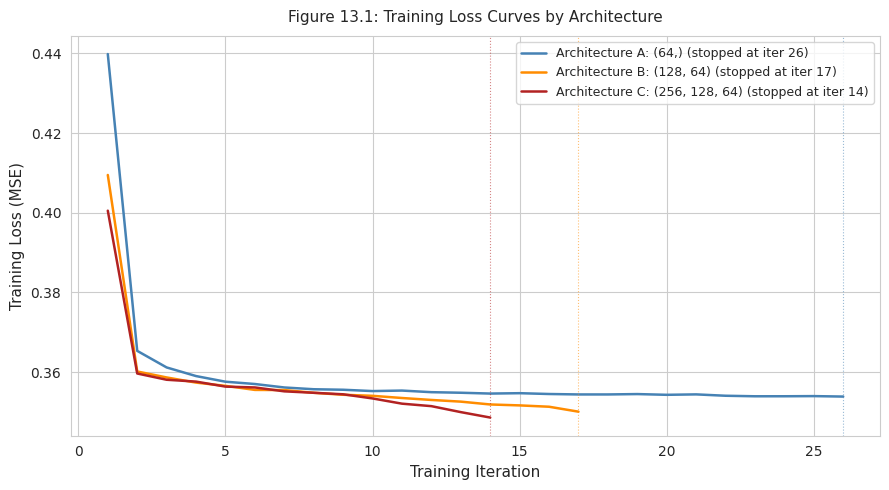

Saved: ../figures/ch13/figure_13_1_training_loss.png


In [15]:
# ── Figure 13.1: Training Loss Curves ─────────────────────────────────────────
#
# loss_curve_ records the training MSE loss at the end of each iteration.
# Each architecture stops at a different point due to early stopping.

fig, ax = plt.subplots(figsize=(9, 5))

arch_colors = {"A": "steelblue", "B": "darkorange", "C": "firebrick"}

for arch_name, res in results.items():
    curve = res["loss_curve"]
    iters = list(range(1, len(curve) + 1))
    color = arch_colors[arch_name]
    layers_str = str(res["layers"])
    n_iter = res["n_iter"]

    label = f"Architecture {arch_name}: {layers_str} (stopped at iter {n_iter})"
    ax.plot(iters, curve, color=color, linewidth=1.8, label=label)
    ax.axvline(x=n_iter, color=color, linewidth=0.8, linestyle=":", alpha=0.55)

ax.set_xlabel("Training Iteration", fontsize=11)
ax.set_ylabel("Training Loss (MSE)", fontsize=11)
ax.set_title("Figure 13.1: Training Loss Curves by Architecture", fontsize=11, pad=10)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path_131 = os.path.join(FIGURES_DIR, "figure_13_1_training_loss.png")
plt.savefig(fig_path_131, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_131}")

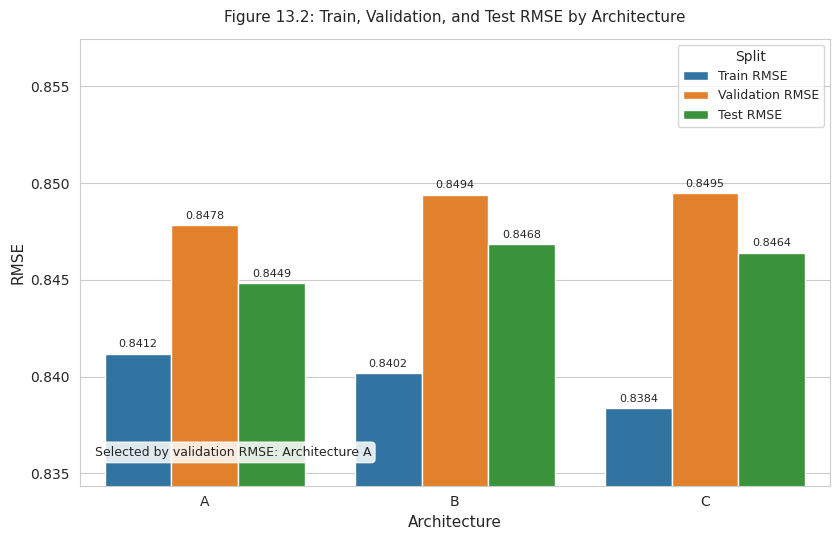

Saved: ../figures/ch13/figure_13_2_architecture_rmse.png
Saved: ../results/ch13/nn_architecture_rmse.csv


,Architecture,Train RMSE,Validation RMSE,Test RMSE,Parameters,Iterations
0,A,0.8412,0.8478,0.8449,1345,26
1,B,0.8402,0.8494,0.8468,10881,17
2,C,0.8384,0.8495,0.8464,46337,14


In [22]:
# ── Figure 13.2: Train, validation, and test RMSE by architecture ─────────────
#
# This figure makes the architecture selection easier to see.
# The y-axis is zoomed to the observed RMSE range because all values are close together.
# Larger networks slightly reduce training RMSE, but validation RMSE determines
# which architecture generalizes best.

architecture_rmse_df = pd.DataFrame([
    {
        "Architecture": arch_name,
        "Train RMSE": res["train_rmse"],
        "Validation RMSE": res["val_rmse"],
        "Test RMSE": res["test_rmse"],
        "Parameters": res["n_params"],
        "Iterations": res["n_iter"]
    }
    for arch_name, res in results.items()
]).sort_values("Architecture")

rmse_long = architecture_rmse_df.melt(
    id_vars=["Architecture", "Parameters", "Iterations"],
    value_vars=["Train RMSE", "Validation RMSE", "Test RMSE"],
    var_name="Split",
    value_name="RMSE"
)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

bar_plot = sns.barplot(
    data=rmse_long,
    x="Architecture",
    y="RMSE",
    hue="Split",
    ax=ax
)

best_arch_by_val = architecture_rmse_df.loc[
    architecture_rmse_df["Validation RMSE"].idxmin(),
    "Architecture"
]

# Zoom y-axis so small RMSE differences are visible
rmse_min = rmse_long["RMSE"].min()
rmse_max = rmse_long["RMSE"].max()
padding = 0.004

ax.set_ylim(rmse_min - padding, rmse_max + padding + 0.004)

# Add value labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        fontsize=8,
        padding=3
    )

ax.set_title(
    "Figure 13.2: Train, Validation, and Test RMSE by Architecture",
    fontsize=11,
    pad=12
)
ax.set_xlabel("Architecture", fontsize=11)
ax.set_ylabel("RMSE", fontsize=11)
ax.legend(fontsize=9, title="Split", loc="upper right")

# Place the selection note below the legend area
ax.text(
    0.02,
    0.06,
    f"Selected by validation RMSE: Architecture {best_arch_by_val}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85)
)

plt.tight_layout()

fig_path_132 = os.path.join(
    FIGURES_DIR,
    "figure_13_2_architecture_rmse.png"
)

plt.savefig(fig_path_132, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_132}")

architecture_rmse_path = os.path.join(
    RESULTS_DIR,
    "nn_architecture_rmse.csv"
)

architecture_rmse_df.to_csv(architecture_rmse_path, index=False)

print(f"Saved: {architecture_rmse_path}")
display(architecture_rmse_df.round(4))

Loading prior regression method results:
  Ch 3 SLR                 : RMSE = 1.5455 (../results/ch03/slr_results.csv)
  Ch 4 MLR                 : RMSE = 0.9000 (../results/ch04/mlr_results.csv)
  Ch 7 Ridge               : RMSE = 0.9003 (../results/ch07/regularization_results.csv)
  Ch 7 Lasso               : RMSE = 0.9003 (../results/ch07/regularization_results.csv)
  Ch 8 Regression Tree     : RMSE = 0.9190 (../results/ch08/trees_results.csv)
  Ch 9 Bagging             : RMSE = 0.8611 (../results/ch09/ensembles_results.csv)
  Ch 9 Random Forest       : RMSE = 0.8559 (../results/ch09/ensembles_results.csv)
  Ch 9 Gradient Boosting   : RMSE = 0.8484 (../results/ch09/ensembles_results.csv)


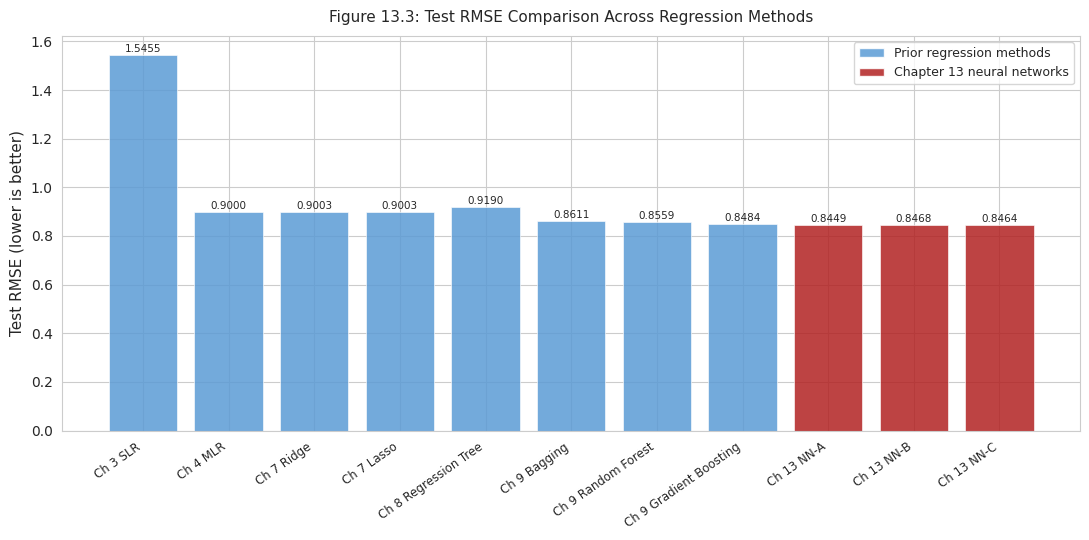

Saved: ../figures/ch13/figure_13_3_regression_method_comparison.png
Saved: ../results/ch13/regression_method_comparison.csv


,Method,Test RMSE,Source
0,Ch 3 SLR,1.54550,../results/ch03/slr_results.csv
1,Ch 4 MLR,0.90000,../results/ch04/mlr_results.csv
2,Ch 7 Ridge,0.90033,../results/ch07/regularization_results.csv
3,Ch 7 Lasso,0.90033,../results/ch07/regularization_results.csv
4,Ch 8 Regression Tree,0.91900,../results/ch08/trees_results.csv
5,Ch 9 Bagging,0.86110,../results/ch09/ensembles_results.csv
6,Ch 9 Random Forest,0.85589,../results/ch09/ensembles_results.csv
7,Ch 9 Gradient Boosting,0.84841,../results/ch09/ensembles_results.csv
8,Ch 13 NN-A,0.84486,this chapter
9,Ch 13 NN-B,0.84684,this chapter


In [17]:
# ── Figure 13.3: Regression-method Test RMSE comparison ───────────────────────
#
# This chart compares only regression methods because RMSE is a regression metric.
# Classification chapters such as SVM and KNN, and the unsupervised PCA chapter,
# are intentionally excluded from this RMSE chart.

prior_methods = [
    {
        "Method": "Ch 3 SLR",
        "Paths": ["../results/ch03/slr_results.csv"],
        "Fallback RMSE": 1.5455,
        "Keywords": None
    },
    {
        "Method": "Ch 4 MLR",
        "Paths": ["../results/ch04/mlr_results.csv"],
        "Fallback RMSE": 0.90036,
        "Keywords": None
    },
    {
        "Method": "Ch 7 Ridge",
        "Paths": ["../results/ch07/ridge_results.csv", "../results/ch07/regularization_results.csv"],
        "Fallback RMSE": 0.90036,
        "Keywords": "Ridge"
    },
    {
        "Method": "Ch 7 Lasso",
        "Paths": ["../results/ch07/lasso_results.csv", "../results/ch07/regularization_results.csv"],
        "Fallback RMSE": 0.90033,
        "Keywords": "Lasso"
    },
    {
        "Method": "Ch 8 Regression Tree",
        "Paths": ["../results/ch08/trees_results.csv", "../results/ch08/tree_results.csv"],
        "Fallback RMSE": 0.9190,
        "Keywords": "Regression"
    },
    {
        "Method": "Ch 9 Bagging",
        "Paths": ["../results/ch09/ensembles_results.csv", "../results/ch09/bagging_results.csv"],
        "Fallback RMSE": 0.86110,
        "Keywords": "Bagging"
    },
    {
        "Method": "Ch 9 Random Forest",
        "Paths": ["../results/ch09/ensembles_results.csv", "../results/ch09/rf_results.csv"],
        "Fallback RMSE": 0.85589,
        "Keywords": "Random Forest Regressor"
    },
    {
        "Method": "Ch 9 Gradient Boosting",
        "Paths": ["../results/ch09/ensembles_results.csv", "../results/ch09/gbm_results.csv"],
        "Fallback RMSE": 0.84841,
        "Keywords": "Gradient Boosting Regressor"
    },
]

comparison_rows = []

print("Loading prior regression method results:")

for item in prior_methods:
    rmse_val, source = load_chapter_rmse(
        item["Paths"],
        fallback=item["Fallback RMSE"],
        model_contains=item["Keywords"]
    )

    comparison_rows.append({
        "Method": item["Method"],
        "Test RMSE": rmse_val,
        "Source": source
    })

    print(f"  {item['Method']:<25}: RMSE = {rmse_val:.4f} ({source})")

for arch_name, res in results.items():
    comparison_rows.append({
        "Method": f"Ch 13 NN-{arch_name}",
        "Test RMSE": res["test_rmse"],
        "Source": "this chapter"
    })

method_comparison_df = pd.DataFrame(comparison_rows)

# Plot in report order
plot_df = method_comparison_df.copy()
plot_df["Group"] = np.where(plot_df["Method"].str.contains("Ch 13"), "Neural Network", "Prior Regression Method")

fig, ax = plt.subplots(figsize=(11, 5.5))

bar_colors = plot_df["Group"].map({
    "Prior Regression Method": "#5B9BD5",
    "Neural Network": "firebrick"
})

bars = ax.bar(
    range(len(plot_df)),
    plot_df["Test RMSE"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85
)

for bar, val in zip(bars, plot_df["Test RMSE"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.004,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=7.5
    )

ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df["Method"], rotation=35, ha="right", fontsize=8.5)
ax.set_ylabel("Test RMSE (lower is better)", fontsize=11)
ax.set_title("Figure 13.3: Test RMSE Comparison Across Regression Methods", fontsize=11, pad=10)

legend_elements = [
    mpatches.Patch(facecolor="#5B9BD5", alpha=0.85, label="Prior regression methods"),
    mpatches.Patch(facecolor="firebrick", alpha=0.85, label="Chapter 13 neural networks")
]
ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
fig_path_133 = os.path.join(FIGURES_DIR, "figure_13_3_regression_method_comparison.png")
plt.savefig(fig_path_133, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_133}")

method_comparison_path = os.path.join(RESULTS_DIR, "regression_method_comparison.csv")
method_comparison_df.to_csv(method_comparison_path, index=False)

print(f"Saved: {method_comparison_path}")
display(method_comparison_df.round(5))

## §6. Diagnostics and Tuning

The architecture with the lowest validation RMSE is selected to carry forward. Validation RMSE is the right selection criterion here because it uses data the model never saw during weight updates. Training RMSE alone is not reliable: larger architectures naturally fit more of the training data without necessarily generalizing better, so comparing architectures by training loss would favor complexity even when the extra complexity is not useful.

The diagnostic figures below examine the selected architecture. Figure 13.4 uses a 2,000-row random sample from the test set to check whether predicted burnout scores follow actual burnout scores. Figure 13.5 uses the full 40,000-row test set to examine whether residuals are centered around zero and whether errors change across the prediction range.

Best architecture by validation RMSE: Architecture A
  Hidden layers        : (64,)
  Trainable parameters : 1,345
  Stopped at iteration : 26
  Train RMSE           : 0.8412
  Val RMSE             : 0.8478
  Test RMSE            : 0.8449
  Test R-squared       : 0.7419


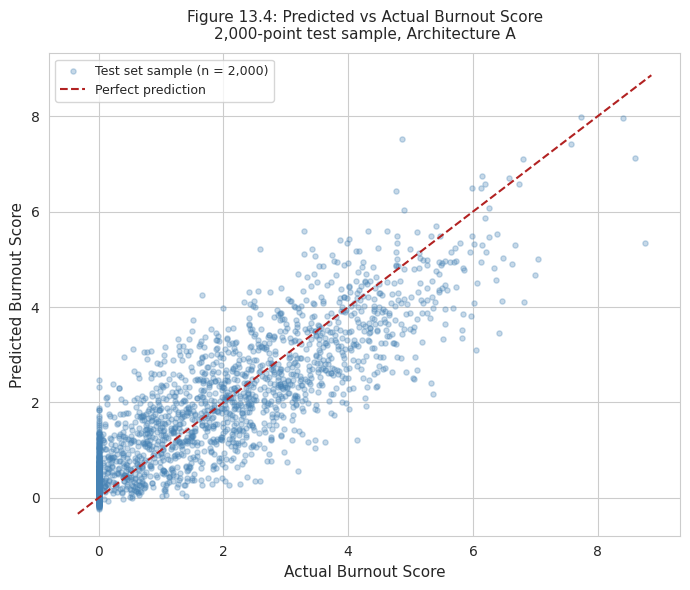

Saved: ../figures/ch13/figure_13_4_predicted_vs_actual.png


In [18]:
# ── Select best architecture by validation RMSE ──────────────────────────────

best_arch = min(results, key=lambda k: results[k]["val_rmse"])
best_res = results[best_arch]

best_layers = str(best_res["layers"])
best_n_params = best_res["n_params"]
best_n_iter = best_res["n_iter"]
best_train = best_res["train_rmse"]
best_val = best_res["val_rmse"]
best_test = best_res["test_rmse"]
best_r2 = best_res["test_r2"]

print(f"Best architecture by validation RMSE: Architecture {best_arch}")
print(f"  Hidden layers        : {best_layers}")
print(f"  Trainable parameters : {best_n_params:,}")
print(f"  Stopped at iteration : {best_n_iter}")
print(f"  Train RMSE           : {best_train:.4f}")
print(f"  Val RMSE             : {best_val:.4f}")
print(f"  Test RMSE            : {best_test:.4f}")
print(f"  Test R-squared       : {best_r2:.4f}")


# ── Figure 13.4: Predicted vs actual burnout score ───────────────────────────
# The model is evaluated on the full test set, but a 2,000-point sample is plotted
# so the figure remains readable in the report.

rng_plot = np.random.default_rng(RANDOM_STATE)
sample_idx = rng_plot.choice(len(y_test_reg), size=2000, replace=False)

y_actual_sample = y_test_reg[sample_idx]
y_pred_sample = best_res["model"].predict(X_test[sample_idx])

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    y_actual_sample,
    y_pred_sample,
    alpha=0.30,
    s=14,
    color="steelblue",
    label="Test set sample (n = 2,000)"
)

lo = min(y_actual_sample.min(), y_pred_sample.min()) - 0.1
hi = max(y_actual_sample.max(), y_pred_sample.max()) + 0.1

ax.plot(
    [lo, hi],
    [lo, hi],
    color="firebrick",
    linewidth=1.5,
    linestyle="--",
    label="Perfect prediction"
)

ax.set_xlabel("Actual Burnout Score", fontsize=11)
ax.set_ylabel("Predicted Burnout Score", fontsize=11)
ax.set_title(
    f"Figure 13.4: Predicted vs Actual Burnout Score\n"
    f"2,000-point test sample, Architecture {best_arch}",
    fontsize=11,
    pad=10
)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path_134 = os.path.join(FIGURES_DIR, "figure_13_4_predicted_vs_actual.png")
plt.savefig(fig_path_134, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_134}")

Residual mean : -0.0112 (near 0 means no systematic bias)
Residual std  : 0.8448 (matches test RMSE = 0.8449)


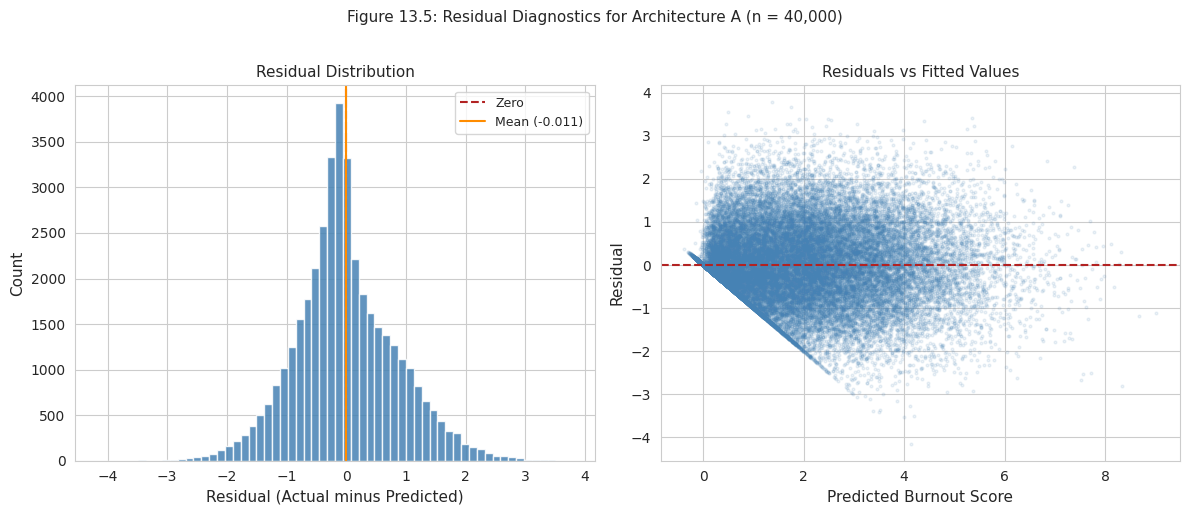

Saved: ../figures/ch13/figure_13_5_residuals.png


In [19]:
# ── Figure 13.5: Residual diagnostics using the full test set ────────────────

y_test_pred_all = best_res["model"].predict(X_test)
residuals = y_test_reg - y_test_pred_all

res_mean = residuals.mean()
res_std = residuals.std()

print(f"Residual mean : {res_mean:.4f} (near 0 means no systematic bias)")
print(f"Residual std  : {res_std:.4f} (matches test RMSE = {best_test:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: histogram
axes[0].hist(residuals, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="firebrick", linewidth=1.5, linestyle="--", label="Zero")
axes[0].axvline(res_mean, color="darkorange", linewidth=1.5, linestyle="-", label=f"Mean ({res_mean:.3f})")
axes[0].set_xlabel("Residual (Actual minus Predicted)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Residual Distribution", fontsize=11)
axes[0].legend(fontsize=9)

# Right: residuals vs fitted
axes[1].scatter(
    y_test_pred_all,
    residuals,
    alpha=0.10,
    s=4,
    color="steelblue",
    rasterized=True
)
axes[1].axhline(0, color="firebrick", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Predicted Burnout Score", fontsize=11)
axes[1].set_ylabel("Residual", fontsize=11)
axes[1].set_title("Residuals vs Fitted Values", fontsize=11)

fig.suptitle(
    f"Figure 13.5: Residual Diagnostics for Architecture {best_arch} (n = {len(y_test_reg):,})",
    fontsize=11,
    y=1.02
)

plt.tight_layout()
fig_path_135 = os.path.join(FIGURES_DIR, "figure_13_5_residuals.png")
plt.savefig(fig_path_135, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_135}")

## §7. Findings

Table 13.2 summarizes all three neural network architectures on the training, validation, and test splits. Table 13.3 compares the selected neural network to the most important benchmarks: the simple linear model from Chapter 3, the multiple linear regression model from Chapter 4, and the best Chapter 9 ensemble model.

In [20]:
# ── Table 13.2: Neural network architecture comparison ───────────────────────

rows = []

for arch_name, res in results.items():
    rows.append({
        "Architecture": arch_name,
        "Hidden Layers": str(res["layers"]),
        "Parameters": res["n_params"],
        "Iterations": res["n_iter"],
        "Train RMSE": round(res["train_rmse"], 4),
        "Val RMSE": round(res["val_rmse"], 4),
        "Test RMSE": round(res["test_rmse"], 4),
        "Test R-squared": round(res["test_r2"], 4),
    })

results_df = pd.DataFrame(rows)

print("Table 13.2: Neural network architecture comparison.")
display(results_df)

csv_path = os.path.join(RESULTS_DIR, "nn_results.csv")
results_df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")


# ── Table 13.3: Improvement over key benchmarks ──────────────────────────────

best_row = results_df.loc[results_df["Val RMSE"].idxmin()]
best_nn_arch = best_row["Architecture"]
best_nn_rmse = float(best_row["Test RMSE"])
best_nn_r2 = float(best_row["Test R-squared"])

slr_rmse = float(method_comparison_df.loc[method_comparison_df["Method"] == "Ch 3 SLR", "Test RMSE"].iloc[0])
mlr_rmse = float(method_comparison_df.loc[method_comparison_df["Method"] == "Ch 4 MLR", "Test RMSE"].iloc[0])

ch09_mask = method_comparison_df["Method"].str.contains("Ch 9", case=False, na=False)
best_ch09_row = method_comparison_df.loc[ch09_mask].sort_values("Test RMSE").iloc[0]
best_ch09_method = best_ch09_row["Method"]
best_ch09_rmse = float(best_ch09_row["Test RMSE"])

benchmark_rows = [
    {
        "Benchmark": "Chapter 3 SLR",
        "Benchmark RMSE": slr_rmse,
        "Selected NN RMSE": best_nn_rmse,
        "Absolute RMSE Difference": slr_rmse - best_nn_rmse,
        "Percent RMSE Reduction": (slr_rmse - best_nn_rmse) / slr_rmse * 100
    },
    {
        "Benchmark": "Chapter 4 MLR",
        "Benchmark RMSE": mlr_rmse,
        "Selected NN RMSE": best_nn_rmse,
        "Absolute RMSE Difference": mlr_rmse - best_nn_rmse,
        "Percent RMSE Reduction": (mlr_rmse - best_nn_rmse) / mlr_rmse * 100
    },
    {
        "Benchmark": best_ch09_method,
        "Benchmark RMSE": best_ch09_rmse,
        "Selected NN RMSE": best_nn_rmse,
        "Absolute RMSE Difference": best_ch09_rmse - best_nn_rmse,
        "Percent RMSE Reduction": (best_ch09_rmse - best_nn_rmse) / best_ch09_rmse * 100
    }
]

benchmark_df = pd.DataFrame(benchmark_rows)

print()
print(f"Selected architecture by validation RMSE: Architecture {best_nn_arch}")
print(f"Selected NN Test RMSE: {best_nn_rmse:.4f}")
print()
print("Table 13.3: Selected neural network improvement over key benchmarks.")
display(benchmark_df.round(4))

benchmark_path = os.path.join(RESULTS_DIR, "nn_benchmark_comparison.csv")
benchmark_df.to_csv(benchmark_path, index=False)
print(f"Saved: {benchmark_path}")

Table 13.2: Neural network architecture comparison.


,Architecture,Hidden Layers,Parameters,Iterations,Train RMSE,Val RMSE,Test RMSE,Test R-squared
0,A,"(64,)",1345,26,0.8412,0.8478,0.8449,0.7419
1,B,"(128, 64)",10881,17,0.8402,0.8494,0.8468,0.7407
2,C,"(256, 128, 64)",46337,14,0.8384,0.8495,0.8464,0.7409


Saved: ../results/ch13/nn_results.csv

Selected architecture by validation RMSE: Architecture A
Selected NN Test RMSE: 0.8449

Table 13.3: Selected neural network improvement over key benchmarks.


,Benchmark,Benchmark RMSE,Selected NN RMSE,Absolute RMSE Difference,Percent RMSE Reduction
0,Chapter 3 SLR,1.5455,0.8449,0.7006,45.3316
1,Chapter 4 MLR,0.9000,0.8449,0.0551,6.1222
2,Ch 9 Gradient Boosting,0.8484,0.8449,0.0035,0.4132


Saved: ../results/ch13/nn_benchmark_comparison.csv


## §8. Real-World Decision

The neural network results are directly comparable to the earlier regression methods on the same 40,000-row test set. For a student wellbeing advising system, the relevant question is not simply whether the neural network achieves the lowest RMSE, but whether the improvement over the best interpretable alternative is large enough to justify a model that cannot explain its predictions.

The selected neural network improves greatly over the simple linear model and modestly over multiple linear regression. However, its improvement over the best Chapter 9 ensemble model is very small. On a burnout score scaled from 0 to 10, a difference of only a few thousandths of an RMSE point is unlikely to change advising decisions in practice. The more important constraint is interpretability. A counselor who flags a student for intervention needs to explain what patterns in that student's profile drove the decision. Gradient boosting from Chapter 9 provides a feature importance ranking that makes that conversation possible. The neural network does not provide that explanation without additional post-hoc tools.

The practical recommendation is to treat the neural network as a research-stage comparison model rather than the primary advising model. The best interpretable ensemble from Chapter 9 remains the more defensible deployment choice unless the neural network produces a much larger performance gain.

## §9. Caveats and Limitations

The neural network trained here offers no mechanism for attributing a prediction to specific input
features, which means any substantive claim about which variables drive burnout must be borrowed from
the interpretable methods in earlier chapters rather than derived from this model. The results are also
sensitive to architectural choices and hyperparameters that are not exhaustively searched here: a
different learning rate, batch size, or hidden layer configuration could produce meaningfully different
test performance, and the three architectures tested represent a small corner of the full design space.
The model also cannot be updated incrementally as new student records arrive and must be retrained from
scratch on the full dataset whenever the underlying data changes, which is computationally expensive at
140,000 rows and requires dedicated infrastructure to be practical at any deployment scale.

In [21]:
# ── Chapter 13 complete ───────────────────────────────────────────────────────

print("Chapter 13 complete.")
print()

print("Figures saved:")
for p in [fig_path_131, fig_path_132, fig_path_133, fig_path_134, fig_path_135]:
    print(f" {p}")

print()

print("Results saved:")
for p in [
    architecture_table_path,
    architecture_rmse_path,
    method_comparison_path,
    csv_path,
    benchmark_path
]:
    print(f" {p}")

Chapter 13 complete.

Figures saved:
 ../figures/ch13/figure_13_1_training_loss.png
 ../figures/ch13/figure_13_2_architecture_rmse.png
 ../figures/ch13/figure_13_3_regression_method_comparison.png
 ../figures/ch13/figure_13_4_predicted_vs_actual.png
 ../figures/ch13/figure_13_5_residuals.png

Results saved:
 ../results/ch13/nn_architecture_table.csv
 ../results/ch13/nn_architecture_rmse.csv
 ../results/ch13/regression_method_comparison.csv
 ../results/ch13/nn_results.csv
 ../results/ch13/nn_benchmark_comparison.csv
